# CELL 1 — Environment Setup & Imports

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import ipywidgets as widgets

# Add CellViT repo to PYTHONPATH
sys.path.append("../CellViT-plus-plus")

# Using the official CellViT inference utilities
from cellvit.training.evaluate.inference_cellvit_experiment_pannuke import InferenceCellViT
from cellvit.training.trainer.trainer_cellvit import CellViTTrainer


# CELL 2 — Load input image (256x256 PNG)

Loaded image: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/fold0/images/TCGA-55-1594-01Z-00-DX1_001_0_768.png
Shape: (256, 256, 3)
Dtype: uint8
Min / Max: 19 255


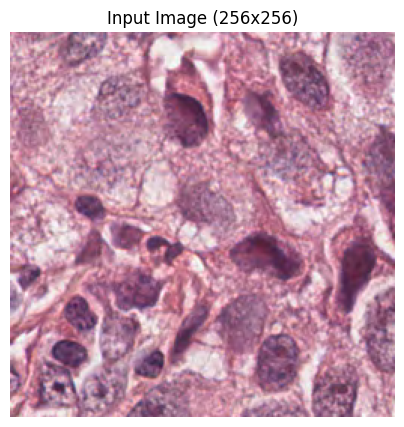

In [2]:
IMAGE_PATH = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/fold0/images/TCGA-55-1594-01Z-00-DX1_001_0_768.png"

assert os.path.exists(IMAGE_PATH), f"Image not found: {IMAGE_PATH}"

img = Image.open(IMAGE_PATH).convert("RGB")
img_np = np.array(img)

print("Loaded image:", IMAGE_PATH)
print("Shape:", img_np.shape)
print("Dtype:", img_np.dtype)
print("Min / Max:", img_np.min(), img_np.max())

plt.figure(figsize=(5,5))
plt.imshow(img_np)
plt.title("Input Image (256x256)")
plt.axis("off")
plt.show()


# CELL 3&4 

## A- Load downloaded log folder
## B- Download log folder from HuggingFace

In [3]:
#A- Load downloaded log folder
 
import sys
import torch

from cellvit.training.evaluate.inference_cellvit_experiment_pannuke import InferenceCellViT

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

RUN_DIR = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2025-12-05T191217_film256"

CHECKPOINT_NAME = "model_best.pth" # Change this if necessary
MAGNIFICATION = 40  # same as training

# Build inference utility
inference = InferenceCellViT(
    run_dir=RUN_DIR,
    gpu=0,
    checkpoint_name=CHECKPOINT_NAME,
    magnification=MAGNIFICATION,
)

# This gives:
# - trained_model: the Virchow model already restored
# - val_loader:    the SAME transforms used during training
# - dataset_config: nuclei/tissue class mapping
trained_model, val_loader, dataset_config = inference.setup_patch_inference()

trained_model = trained_model.to(device).eval()

print("Validation loader length:", len(val_loader))
print("Dataset config:", dataset_config)


Using device: cuda
Loaded run: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2025-12-05T191217_film256
Loading best model from /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2025-12-05T191217_film256/checkpoints/model_best.pth
<All keys matched successfully>
There was no test set provided. We now use the validation dataset for testing
Performing Inference on test set: [1]
Validation loader length: 2
Dataset config: {'name': 'TCGA', 'magnification': 40, 'patch_size': 256, 'num_classes': 1, 'stain_normalized': False, 'description': 'TCGA Lung patches prepared for CellViT fine-tuning', 'tissue_types': {'Lung': 0}, 'nuclei_types': {'background': 0, 'epithelial': 1, 'lymphocyte': 2, 'macrophage': 3, 'neutroph

# CELL 4 — Load CellViT Model via Hugging Face

In [ ]:
# B- Download log folder from HuggingFace

import torch
from huggingface_hub import snapshot_download
from cellvit.training.evaluate.inference_cellvit_experiment_pannuke import InferenceCellViT

# -------------------------------------------------
# Device
# -------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# -------------------------------------------------
# Hugging Face model run
# -------------------------------------------------
HF_REPO_ID = "BerkTuzcuBU/CellViT-FiLM-256-Run"

RUN_DIR = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir="./runs/cellvit_film_256",
    local_dir_use_symlinks=False,
)

print("Model run downloaded to:", RUN_DIR)

# -------------------------------------------------
# Inference configuration
# -------------------------------------------------
CHECKPOINT_NAME = "model_best.pth"
MAGNIFICATION = 40   # must match training

# -------------------------------------------------
# Build inference utility
# -------------------------------------------------
inference = InferenceCellViT(
    run_dir=RUN_DIR,
    gpu=0 if device == "cuda" else None,
    checkpoint_name=CHECKPOINT_NAME,
    magnification=MAGNIFICATION,
)

# -------------------------------------------------
# Restore model + validation loader
# (uses EXACT training transforms)
# -------------------------------------------------
trained_model, val_loader, dataset_config = inference.setup_patch_inference()

trained_model = trained_model.to(device).eval()

print("Validation loader length:", len(val_loader))
print("Nuclei types:", dataset_config["nuclei_types"])


# Load checkpoint from RUN_DIR

In [4]:
ckpt = torch.load(RUN_DIR+"/checkpoints/model_best.pth", map_location="cpu", weights_only=False)
print(ckpt["arch"])


CellViTSAMRosieFiLM


# CELL 4 — Inference using with EXACT Training Transforms + Postprocessing

binary min/max: 2.3387041e-07 0.99999964
hv range: -1.0106816 1.070026
unique instances: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


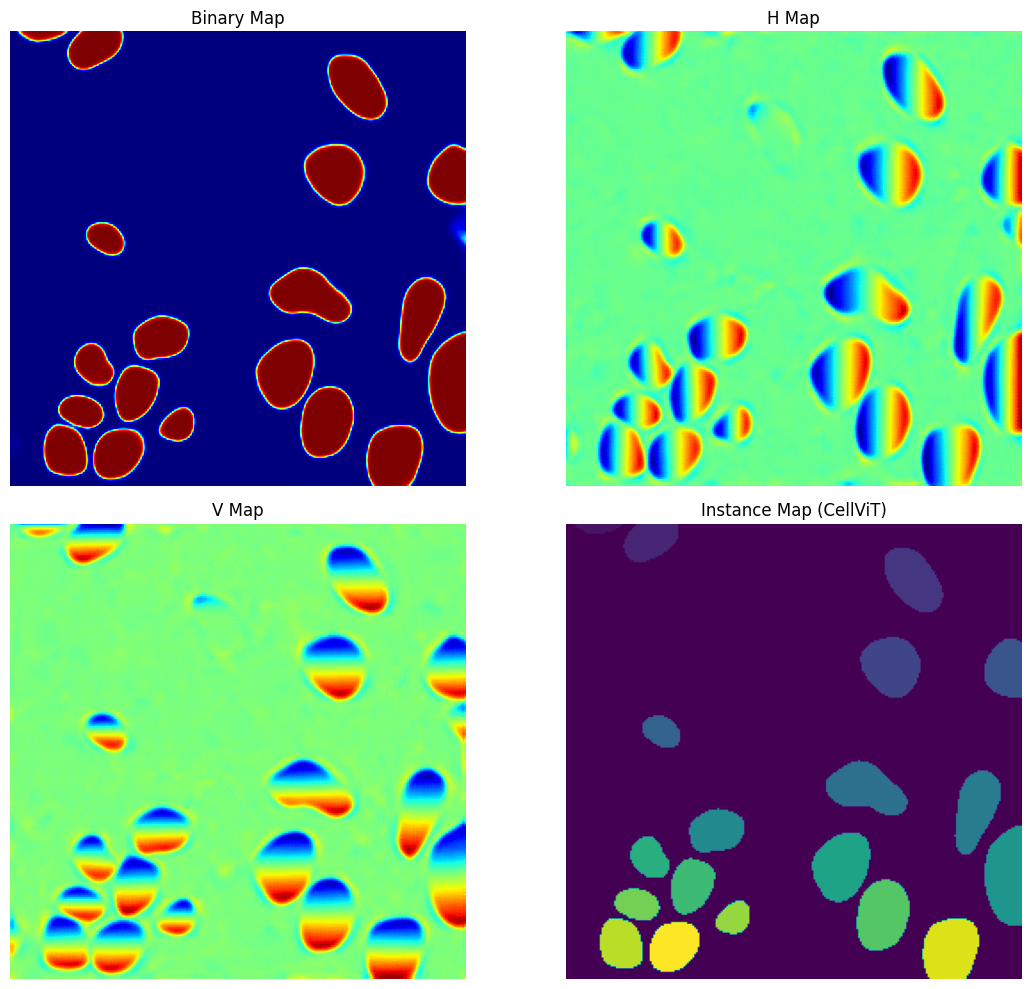

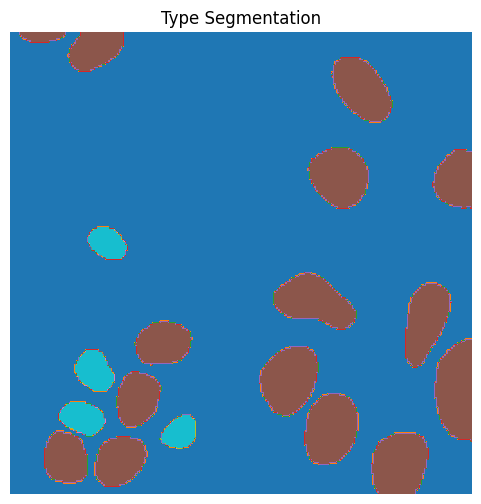

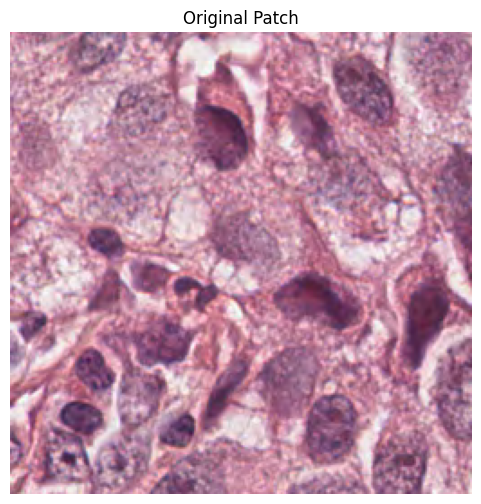

In [5]:
from PIL import Image
import numpy as np
import torch

# ------------------- 1) Load your image -------------------
img_np   = np.array(img)

# Build a dummy trainer just for postprocessing
dummy_opt = torch.optim.SGD(trained_model.parameters(), lr=0.1)
dummy_sched = torch.optim.lr_scheduler.StepLR(dummy_opt, step_size=1000, gamma=1.0)

trainer = CellViTTrainer(
    model=trained_model,
    loss_fn_dict={},
    optimizer=dummy_opt,
    scheduler=dummy_sched,
    device=device,
    logger=inference.logger,
    logdir=RUN_DIR,
    num_classes=len(dataset_config["nuclei_types"]),
    dataset_config=dataset_config,
    experiment_config={},
    early_stopping=None,
    log_images=False,
    magnification=MAGNIFICATION,
    mixed_precision=False,
)

# ------------------- 2) Apply SAME transforms as val set -------------------
ds  = val_loader.dataset
tfm = getattr(ds, "transforms", None) or getattr(ds, "transform", None)

if tfm is None:
    raise RuntimeError("Dataset has no transform attribute.")

# Albumentations transform
try:
    transformed = tfm(image=img_np)
    img_t = transformed["image"]
except TypeError:
    # Torchvision transform
    img_t = tfm(img)

# ------------------- 3) Ensure output is a CHW torch tensor -------------------
if isinstance(img_t, np.ndarray):
    if img_t.ndim == 3 and img_t.shape[-1] == 3:
        img_t = torch.from_numpy(img_t).permute(2,0,1)
    else:
        img_t = torch.from_numpy(img_t)
elif isinstance(img_t, torch.Tensor):
    if img_t.ndim == 3 and img_t.shape[-1] == 3:
        img_t = img_t.permute(2,0,1)
else:
    raise TypeError("Unexpected transform output type")

# Make batch
img_batch = img_t.unsqueeze(0).to(device)

# ------------------- 4) Model + Postprocessing -------------------
with torch.no_grad():
    out = trained_model(img_batch)

processed = trainer.unpack_predictions(out)

binary_map = processed.nuclei_binary_map[0,1].cpu().numpy()
hv_map     = processed.hv_map[0].cpu().numpy()
inst_map   = processed.instance_map[0].cpu().numpy().astype(int)
type_map   = torch.argmax(processed.nuclei_type_map, dim=1)[0].cpu().numpy()

print("binary min/max:", binary_map.min(), binary_map.max())
print("hv range:", hv_map.min(), hv_map.max())
print("unique instances:", np.unique(inst_map)[:20])

# ------------------- 5) Visualize -------------------
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
plt.imshow(binary_map, cmap="jet")
plt.title("Binary Map")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(hv_map[0], cmap="jet")
plt.title("H Map")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(hv_map[1], cmap="jet")
plt.title("V Map")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(inst_map)
plt.title("Instance Map (CellViT)")
plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(type_map, cmap="tab10")
plt.title("Type Segmentation")
plt.axis("off")
plt.show()

# -------------------- Original Image -----------------
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Original Patch")
plt.axis("off")
plt.show()


# CELL 6 — Overlay Results on the Original Image (with legend)


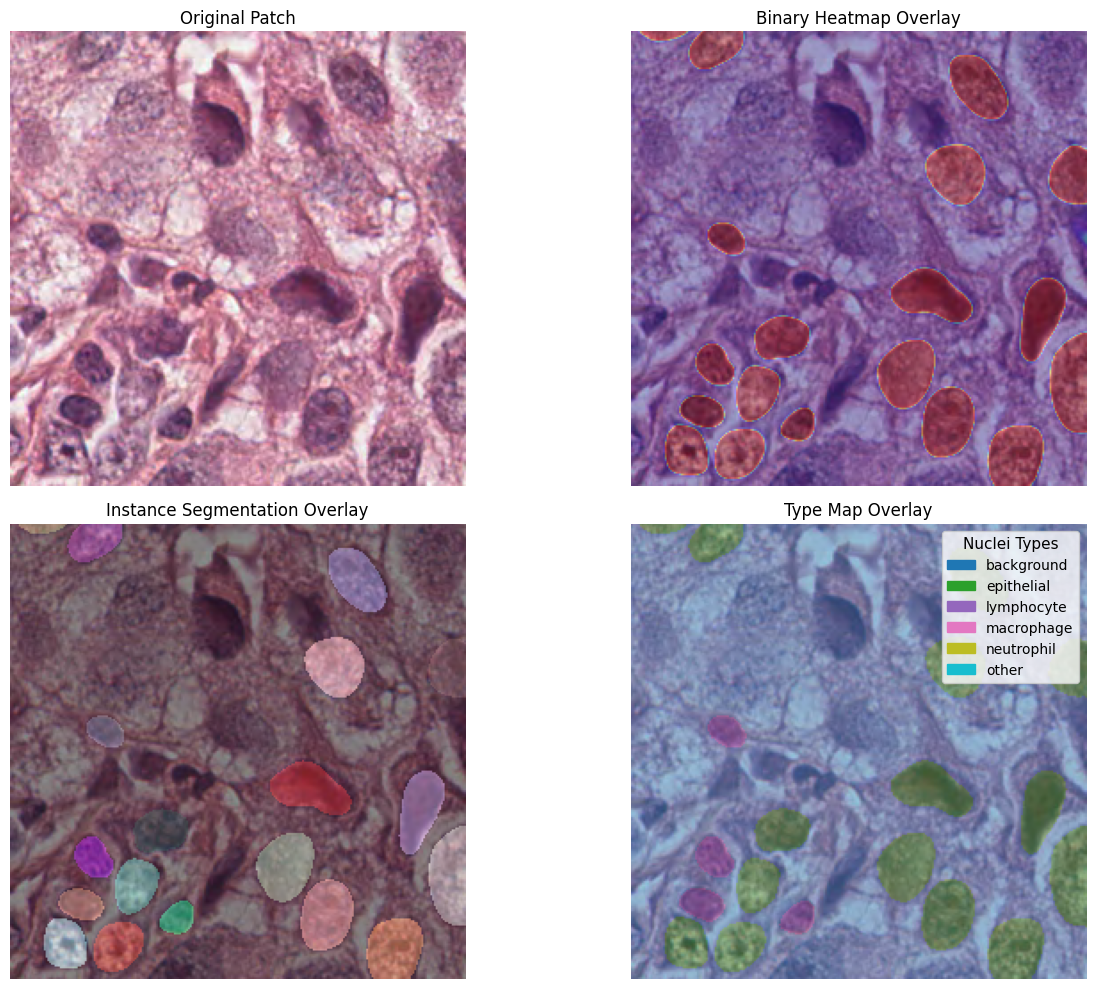

In [6]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 0) Build legend colors from dataset_config automatically ---
nuclei_types = dataset_config["nuclei_types"]        # {"background":0, "epithelial":1, ...}
num_classes  = len(nuclei_types)
cmap = plt.get_cmap("tab10")

# map class name → RGB color (0–255)
type_to_color = {
    cls_name: (np.array(cmap(cls_id / max(1, num_classes-1))[:3]) * 255).astype(np.uint8)
    for cls_name, cls_id in nuclei_types.items()
}

# --- 1) Original RGB image ---
orig = np.array(img).copy()   # use original uploaded image
H, W = binary_map.shape
orig_resized = cv2.resize(orig, (W, H))

# --- 2) Instance segmentation overlay ---
inst_colored = np.zeros((H, W, 3), dtype=np.uint8)
unique_ids = np.unique(inst_map)

for uid in unique_ids:
    if uid == 0: 
        continue
    color = np.random.randint(0, 255, size=3)
    inst_colored[inst_map == uid] = color

overlay_inst = cv2.addWeighted(orig_resized, 0.55, inst_colored, 0.45, 0)

# --- 3) Binary heatmap overlay ---
binary_norm  = (binary_map * 255).astype(np.uint8)
binary_color = cv2.applyColorMap(binary_norm, cv2.COLORMAP_JET)
binary_color = cv2.cvtColor(binary_color, cv2.COLOR_BGR2RGB)

overlay_binary = cv2.addWeighted(orig_resized, 0.65, binary_color, 0.35, 0)

# --- 4) Type map overlay ---
type_color_map = np.zeros((H, W, 3), dtype=np.uint8)
for cls_name, cls_id in nuclei_types.items():
    mask = type_map == cls_id
    type_color_map[mask] = type_to_color[cls_name]

overlay_type = cv2.addWeighted(orig_resized, 0.55, type_color_map, 0.45, 0)

# --- 5) Build legend patches ---
legend_entries = []
for cls_name, rgb in type_to_color.items():
    patch = mpatches.Patch(color=rgb/255.0, label=cls_name)
    legend_entries.append(patch)

# --- 6) Plot everything ---
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

ax[0,0].imshow(orig_resized)
ax[0,0].set_title("Original Patch")
ax[0,0].axis("off")

ax[0,1].imshow(overlay_binary)
ax[0,1].set_title("Binary Heatmap Overlay")
ax[0,1].axis("off")

ax[1,0].imshow(overlay_inst)
ax[1,0].set_title("Instance Segmentation Overlay")
ax[1,0].axis("off")

ax[1,1].imshow(overlay_type)
ax[1,1].set_title("Type Map Overlay")
ax[1,1].axis("off")

# Add legend to the Type Map subplot
ax[1,1].legend(
    handles=legend_entries,
    loc="upper right",
    title="Nuclei Types",
    fontsize=10,
    title_fontsize=11,
    frameon=True
)

plt.tight_layout()
plt.show()


# Side by side visual comparison of different models

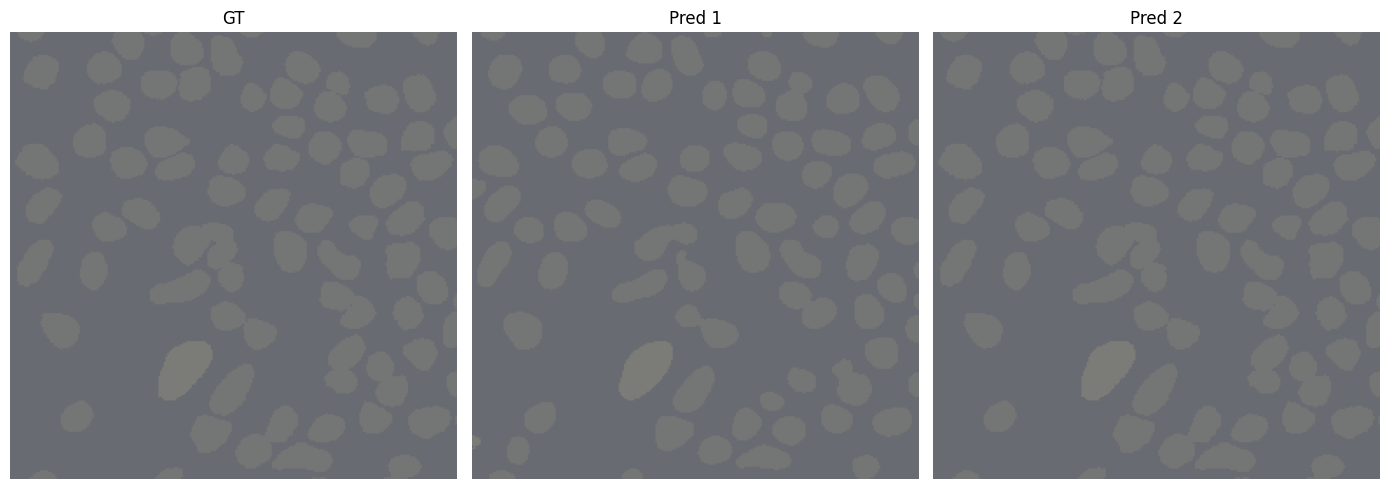

In [7]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def _load_img(path: str) -> np.ndarray:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"Not found: {p}")
    img = Image.open(p)
    return np.array(img)

def _to_display_array(img: np.ndarray) -> np.ndarray:
    """
    Normalize to float in [0,1] for display. Keeps channels if present.
    """
    arr = img.astype(np.float32)

    # If uint-like, scale by max of dtype range
    if np.issubdtype(img.dtype, np.integer):
        maxv = np.iinfo(img.dtype).max
        if maxv > 0:
            arr /= maxv
    else:
        # float: robust normalize if outside [0,1]
        if arr.min() < 0 or arr.max() > 1:
            lo, hi = np.percentile(arr, [1, 99])
            arr = (arr - lo) / (hi - lo + 1e-8)
            arr = np.clip(arr, 0, 1)

    return np.clip(arr, 0, 1)

def show_gt_and_preds(gt_path: str, pred1_path: str, pred2_path: str,
                      titles=("GT", "Pred 1", "Pred 2"),
                      mode="cbf",  # "cbf" or "grayscale" or "raw"
                      cmap="cividis",
                      figsize=(14, 5)):
    """
    mode:
      - "raw": show as-is (RGB stays RGB, grayscale stays grayscale)
      - "grayscale": convert everything to grayscale for maximum clarity
      - "cbf": color-blind friendly colormap (great for single-channel or label maps)
    """
    paths = [gt_path, pred1_path, pred2_path]
    imgs = [_load_img(p) for p in paths]

    fig, axes = plt.subplots(1, 3, figsize=figsize)
    for ax, img, title in zip(axes, imgs, titles):
        ax.set_title(title)
        ax.axis("off")

        # Drop alpha if present
        if img.ndim == 3 and img.shape[-1] == 4:
            img = img[..., :3]

        # Decide how to display
        if mode == "raw":
            disp = _to_display_array(img)
            if disp.ndim == 2:
                ax.imshow(disp, cmap="gray")
            else:
                ax.imshow(disp)

        elif mode == "grayscale":
            # Convert RGB->gray if needed
            if img.ndim == 3:
                rgb = _to_display_array(img)[..., :3]
                gray = 0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2]
                ax.imshow(gray, cmap="gray", vmin=0, vmax=1)
            else:
                ax.imshow(_to_display_array(img), cmap="gray", vmin=0, vmax=1)

        elif mode == "cbf":
            # If RGB, convert to luminance then apply a CVD-friendly colormap
            if img.ndim == 3:
                rgb = _to_display_array(img)[..., :3]
                scalar = 0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2]
                ax.imshow(scalar, cmap=cmap, vmin=0, vmax=1)
            else:
                ax.imshow(_to_display_array(img), cmap=cmap, vmin=0, vmax=1)

        else:
            raise ValueError("mode must be one of: 'raw', 'grayscale', 'cbf'")

    plt.tight_layout()
    plt.show()

# Example usage (replace with your full paths):
show_gt_and_preds("/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local/2025-12-05T174106_tcga_finetune_256/val_previews/epoch_078_idx2_gt_type.png", "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local/2025-12-05T174106_tcga_finetune_256/val_previews/epoch_078_idx2_pred_type.png", "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2025-12-05T191217_film256/val_previews/epoch_079_idx2_gt_type.png", mode="cbf", cmap="cividis")


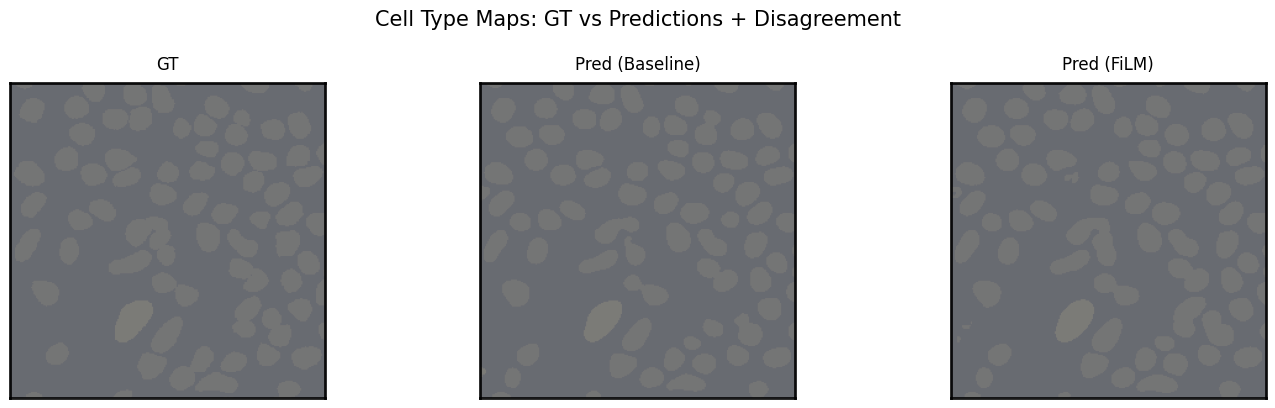

In [8]:
from pathlib import Path
from typing import Dict, Optional, Union, Tuple, List

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from PIL import Image


def _load_img(path: Union[str, Path]) -> np.ndarray:
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"Not found: {p}")
    return np.array(Image.open(p))


def _to_display_array(img: np.ndarray) -> np.ndarray:
    arr = img.astype(np.float32)
    if np.issubdtype(img.dtype, np.integer):
        maxv = np.iinfo(img.dtype).max
        if maxv > 0:
            arr /= maxv
    else:
        if arr.min() < 0 or arr.max() > 1:
            lo, hi = np.percentile(arr, [1, 99])
            arr = (arr - lo) / (hi - lo + 1e-8)
            arr = np.clip(arr, 0, 1)
    return np.clip(arr, 0, 1)


def _rgb_to_luma(rgb01: np.ndarray) -> np.ndarray:
    return 0.2126 * rgb01[..., 0] + 0.7152 * rgb01[..., 1] + 0.0722 * rgb01[..., 2]


def _is_label_map(arr: np.ndarray, max_unique: int = 64) -> bool:
    """
    Heuristic: label map is 2D (or 3D but single channel) integer-like with limited unique values.
    """
    if arr.ndim == 3 and arr.shape[-1] in (3, 4):
        return False
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr[..., 0]
    if arr.ndim != 2:
        return False

    # integer-ish?
    if np.issubdtype(arr.dtype, np.integer):
        uniques = np.unique(arr)
        return len(uniques) <= max_unique

    # float but actually integers?
    if np.issubdtype(arr.dtype, np.floating):
        # sample to avoid huge memory
        sample = arr.ravel()
        if sample.size > 200000:
            idx = np.random.default_rng(0).choice(sample.size, 200000, replace=False)
            sample = sample[idx]
        if np.all(np.isfinite(sample)):
            near_int = np.mean(np.isclose(sample, np.round(sample), atol=1e-6))
            if near_int > 0.995:
                uniques = np.unique(np.round(arr).astype(np.int32))
                return len(uniques) <= max_unique
    return False


def _make_discrete_cmap(class_ids: List[int]) -> Tuple[ListedColormap, BoundaryNorm]:
    """
    Build a discrete colormap indexed by class id order.
    Colors are from Matplotlib 'tab20' (distinct & print-friendly).
    """
    base = plt.get_cmap("tab20").colors  # 20 distinct colors
    # If more than 20 classes, repeat (still consistent)
    colors = [base[i % len(base)] for i in range(len(class_ids))]
    cmap = ListedColormap(colors, name="paper_labels")
    # Boundaries for imshow with integer labels
    boundaries = np.arange(-0.5, len(class_ids) + 0.5, 1.0)
    norm = BoundaryNorm(boundaries, cmap.N)
    return cmap, norm


def plot_paper_comparison(
    name_to_path: Dict[str, Union[str, Path]],
    *,
    gt_key: str = "GT",
    class_id_to_name: Optional[Dict[int, str]] = None,  # e.g. {0:"bg",1:"tumor",...}
    add_disagreement: bool = True,
    max_cols: int = 4,
    title: Optional[str] = None,
    border_px: float = 2.0,
    border_alpha: float = 0.9,
    figsize_per_col: float = 4.8,
    scalar_mode: str = "cbf",   # used when NOT label maps: "cbf" | "grayscale" | "raw"
    scalar_cmap: str = "cividis",
):
    """
    Creates a paper-style grid:
      - If label maps: discrete colormap + legend
      - Optionally adds disagreement panels (Pred vs GT)
      - If not label maps: falls back to scalar display (cbf/grayscale/raw)
    """
    if gt_key not in name_to_path:
        raise ValueError(f"gt_key='{gt_key}' not found in name_to_path keys: {list(name_to_path.keys())}")

    # Load all
    names = list(name_to_path.keys())
    imgs = {name: _load_img(path) for name, path in name_to_path.items()}

    # Decide if we're in label-map mode (based on GT)
    gt_img = imgs[gt_key]
    is_labels = _is_label_map(gt_img)

    # Prepare panels
    panels = []  # list of (panel_title, array, kind)
    # kind: "labels" | "scalar" | "rgb" | "disagree"

    if is_labels:
        # Collect class ids across ALL maps (GT + preds) for consistent mapping
        all_ids = set()
        for arr in imgs.values():
            a = arr
            if a.ndim == 3 and a.shape[-1] == 1:
                a = a[..., 0]
            if np.issubdtype(a.dtype, np.floating):
                a = np.round(a).astype(np.int32)
            all_ids.update(np.unique(a).tolist())
        class_ids = sorted(list(all_ids))

        # Map each actual class id -> index 0..K-1 for BoundaryNorm
        id_to_idx = {cid: i for i, cid in enumerate(class_ids)}

        cmap, norm = _make_discrete_cmap(class_ids)

        def to_idx_map(arr: np.ndarray) -> np.ndarray:
            a = arr
            if a.ndim == 3 and a.shape[-1] == 1:
                a = a[..., 0]
            if np.issubdtype(a.dtype, np.floating):
                a = np.round(a).astype(np.int32)
            out = np.zeros_like(a, dtype=np.int32)
            # vectorized remap
            # (works best when labels are non-negative; but okay either way)
            for cid, idx in id_to_idx.items():
                out[a == cid] = idx
            return out

        gt_idx = to_idx_map(gt_img)

        # Main panels
        for name in names:
            arr = imgs[name]
            panels.append((name, to_idx_map(arr), "labels"))

        # Disagreement panels for preds (everything except GT)
        if add_disagreement:
            for name in names:
                if name == gt_key:
                    continue
                pred_idx = to_idx_map(imgs[name])
                disagree = (pred_idx != gt_idx).astype(np.uint8)  # 0/1
                mismatch = 100.0 * disagree.mean()
                panels.append((f"{name} vs {gt_key}\nMismatch: {mismatch:.2f}%", disagree, "disagree"))

        # Legend patches (class names if provided)
        legend_items = []
        for cid in class_ids:
            label = class_id_to_name.get(cid, str(cid)) if class_id_to_name else str(cid)
            legend_items.append((cid, label))

    else:
        # Scalar / RGB mode
        for name in names:
            arr = imgs[name]
            # drop alpha
            if arr.ndim == 3 and arr.shape[-1] == 4:
                arr = arr[..., :3]

            if scalar_mode == "raw":
                disp = _to_display_array(arr)
                kind = "rgb" if disp.ndim == 3 else "scalar"
                panels.append((name, disp, kind))
            elif scalar_mode == "grayscale":
                if arr.ndim == 3:
                    rgb = _to_display_array(arr)[..., :3]
                    gray = _rgb_to_luma(rgb)
                    panels.append((name, gray, "scalar"))
                else:
                    panels.append((name, _to_display_array(arr), "scalar"))
            elif scalar_mode == "cbf":
                if arr.ndim == 3:
                    rgb = _to_display_array(arr)[..., :3]
                    scalar = _rgb_to_luma(rgb)
                    panels.append((name, scalar, "scalar"))
                else:
                    panels.append((name, _to_display_array(arr), "scalar"))
            else:
                raise ValueError("scalar_mode must be one of: 'raw', 'grayscale', 'cbf'")

        legend_items = None
        cmap = None
        norm = None

    # Grid sizing
    n = len(panels)
    ncols = min(max_cols, n)
    nrows = (n + ncols - 1) // ncols
    figsize = (figsize_per_col * ncols, figsize_per_col * 0.85 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)

    disagree_cmap = ListedColormap([(0, 0, 0, 0.0), (1, 1, 1, 1.0)])  # transparent vs white
    last_im = None

    for i, (ptitle, arr, kind) in enumerate(panels):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        ax.set_title(ptitle, fontsize=12, pad=10)
        ax.set_xticks([])
        ax.set_yticks([])

        if kind == "labels":
            last_im = ax.imshow(arr, cmap=cmap, norm=norm, interpolation="nearest")
        elif kind == "disagree":
            # show mismatches as white on black background
            last_im = ax.imshow(arr, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        elif kind == "rgb":
            last_im = ax.imshow(arr)
        else:  # scalar
            last_im = ax.imshow(arr, cmap=scalar_cmap, vmin=0, vmax=1)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(border_px)
            spine.set_alpha(border_alpha)

    # Hide unused axes
    for j in range(n, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis("off")

    if title:
        fig.suptitle(title, fontsize=15, y=0.99)

    # Add legend for label maps
    if is_labels and legend_items is not None:
        # Build patches in the same order as class_ids
        patches = []
        for cid, label in legend_items:
            idx = id_to_idx[cid]
            color = cmap.colors[idx]
            patches.append(Patch(facecolor=color, edgecolor="black", label=label))
        # Place legend below figure
        fig.legend(
            handles=patches,
            loc="lower center",
            ncol=min(len(patches), max(3, ncols)),
            frameon=False,
            bbox_to_anchor=(0.5, -0.01),
            fontsize=10,
        )
        plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    else:
        plt.tight_layout()

    plt.show()


# -----------------------
# Example usage
# -----------------------
name_to_path = {
    "GT": "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local/2025-12-05T174106_tcga_finetune_256/val_previews/epoch_078_idx2_gt_type.png",
    "Pred (Baseline)": "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local/2025-12-05T174106_tcga_finetune_256/val_previews/epoch_078_idx2_pred_type.png",
    "Pred (FiLM)": "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/ProcessedDataset/v1_40x_area20_2/patches_cellvit_p256_pannuke/logs_local_berk/2025-12-05T191217_film256/val_previews/epoch_079_idx2_pred_type.png",
}

# If you know class names, pass them for a proper legend:
# class_id_to_name = {0:"Background", 1:"Neoplastic", 2:"Inflammatory", ...}

plot_paper_comparison(
    name_to_path,
    gt_key="GT",
    class_id_to_name=None,         # or provide mapping
    add_disagreement=True,
    max_cols=3,
    title="Cell Type Maps: GT vs Predictions + Disagreement",
)
